# 🔍 Fake News Detection — LSTM Model Training

**Dataset:** True.csv + Fake.csv (Kaggle)

**Data Split:** 80% Training | 10% Testing | 10% Unseen Validation

This notebook trains an LSTM neural network to detect fake news and evaluates on both test and unseen data.

## Step 0: Install Required Libraries

In [4]:
!pip install tensorflow keras nltk scikit-learn pandas numpy matplotlib seaborn -q
print("✅ All libraries installed!")

✅ All libraries installed!


## Step 1: Upload Dataset Files

Upload `True.csv` and `Fake.csv` from your computer

In [5]:
from google.colab import files
import os

print("Assuming True.csv and Fake.csv are already present in the current directory.")
print("Proceeding with data loading.")

Assuming True.csv and Fake.csv are already present in the current directory.
Proceeding with data loading.


## Step 2: Import Libraries & Configure

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 3: Configuration

In [7]:
# Configuration
MAX_VOCAB_SIZE = 10000     # Top N most frequent words
MAX_SEQUENCE_LEN = 300     # Max words per article
EMBEDDING_DIM = 128        # Word embedding dimensions
LSTM_UNITS = 64            # LSTM hidden units
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 20
RANDOM_STATE = 42

# Data Split: 80% Training, 10% Testing, 10% Unseen Validation
TRAIN_SIZE = 0.8
TEST_UNSEEN_SPLIT = 0.5

OUTPUT_DIR = "model_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Configuration loaded!")

✅ Configuration loaded!


## Step 4: Load Data

In [8]:
print("=" * 60)
print("STEP 1: Loading Dataset")
print("=" * 60)

try:
    true_df = pd.read_csv("True.csv")
    fake_df = pd.read_csv("Fake.csv")
except FileNotFoundError:
    print("[ERROR] True.csv or Fake.csv not found!")
    raise

# Label: 1 = Real, 0 = Fake
true_df['label'] = 1
fake_df['label'] = 0

print(f"  Real news articles : {len(true_df)}")
print(f"  Fake news articles : {len(fake_df)}")

# Combine title + text for richer features
true_df['content'] = true_df['title'].fillna('') + " " + true_df['text'].fillna('')
fake_df['content'] = fake_df['title'].fillna('') + " " + fake_df['text'].fillna('')

df = pd.concat([true_df[['content', 'label']], fake_df[['content', 'label']]], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"  Total samples      : {len(df)}")
print(f"  Label distribution:\n{df['label'].value_counts()}\n")

STEP 1: Loading Dataset
  Real news articles : 21417
  Fake news articles : 23481
  Total samples      : 44898
  Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64



## Step 5: Text Preprocessing

In [10]:
def preprocess_text(text):
    """Clean and normalize a single text string."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters & numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and apply stemming
    tokens = [ps.stem(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

print("=" * 60)
print("STEP 2: Preprocessing Text")
print("=" * 60)
print("  Cleaning text (this may take a minute)...")
df['cleaned'] = df['content'].apply(preprocess_text)
print(f"  Sample cleaned text:\n  {df['cleaned'].iloc[0][:150]}...\n")

STEP 2: Preprocessing Text
  Cleaning text (this may take a minute)...
  Sample cleaned text:
  break gop chairman grassley enough demand trump testimoni donald trump white hous chao tri cover russia problem mount hour refus acknowledg problem su...



## Step 6: Tokenize & Pad Sequences

In [11]:
print("=" * 60)
print("STEP 3: Tokenizing & Padding Sequences")
print("=" * 60)

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned'])

sequences = tokenizer.texts_to_sequences(df['cleaned'])
padded = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LEN, padding='post', truncating='post')

print(f"  Vocabulary size    : {len(tokenizer.word_index)}")
print(f"  Sequence shape     : {padded.shape}\n")

# Save tokenizer
with open(os.path.join(OUTPUT_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)
print(f"  Tokenizer saved to {OUTPUT_DIR}/tokenizer.pkl\n")

STEP 3: Tokenizing & Padding Sequences
  Vocabulary size    : 182083
  Sequence shape     : (44898, 300)

  Tokenizer saved to model_artifacts/tokenizer.pkl



## Step 7: Split Data (80:10:10)

In [12]:
X = padded
y = df['label'].values

print("=" * 60)
print("DATA SPLIT: 80% Train, 10% Test, 10% Unseen")
print("=" * 60)

# First split: 80% (train+test) and 20% (unseen) -> Actually 10% unseen
X_temp, X_unseen, y_temp, y_unseen = train_test_split(
    X, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y
)

# Second split: Split temp into train (80%) and test (20%)
# Since temp is 90% of original, 80% of temp = 72% of original
# To get 80% train and 10% test, we split temp by 0.125 to get 10% test from original
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"  Train samples : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test samples  : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Unseen samples: {len(X_unseen)} ({len(X_unseen)/len(X)*100:.1f}%)")
print(f"  Total samples : {len(X)}\n")

DATA SPLIT: 80% Train, 10% Test, 10% Unseen
  Train samples : 35357 (78.7%)
  Test samples  : 5051 (11.2%)
  Unseen samples: 4490 (10.0%)
  Total samples : 44898



## Step 8: Build LSTM Model

In [13]:
print("=" * 60)
print("STEP 4: Building LSTM Model")
print("=" * 60)

model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQUENCE_LEN),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    Dropout(DROPOUT_RATE),
    LSTM(32),
    Dropout(DROPOUT_RATE),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')   # Binary: Real(1) or Fake(0)
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

STEP 4: Building LSTM Model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 9: Train Model

In [14]:
print("\n" + "=" * 60)
print("STEP 5: Training Model")
print("=" * 60)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, "best_model.keras"),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)


STEP 5: Training Model
Epoch 1/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5683 - loss: 0.6730
Epoch 1: val_accuracy improved from None to 0.62780, saving model to model_artifacts/best_model.keras

Epoch 1: finished saving model to model_artifacts/best_model.keras
553/553 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5669 - loss: 0.6729 - val_accuracy: 0.6278 - val_loss: 0.6386
Epoch 2/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8163 - loss: 0.4160
Epoch 2: val_accuracy improved from 0.62780 to 0.98832, saving model to model_artifacts/best_model.keras

Epoch 2: finished saving model to model_artifacts/best_model.keras
553/553 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9000 - loss: 0.2578 - val_accuracy: 0.9883 - val_loss: 0.0395
Epoch 3/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9929 - loss: 0.0322
Epoch 3: val_accuracy improved from 0.98832 to 0.99762, saving model to model_artifacts/best_model.keras

Epoch 3: finished saving mod

## Step 10: Evaluate on Test Set

In [15]:
print("\n" + "=" * 60)
print("STEP 6: Evaluation & Results")
print("=" * 60)

# Predictions on Test Set
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
print(f"\n  Test Set Accuracy: {acc * 100:.2f}%\n")
print("  Test Set Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))


STEP 6: Evaluation & Results

  Test Set Accuracy: 99.92%

  Test Set Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2642
        Real       1.00      1.00      1.00      2409

    accuracy                           1.00      5051
   macro avg       1.00      1.00      1.00      5051
weighted avg       1.00      1.00      1.00      5051



## Step 11: Evaluate on Unseen Data

In [16]:
print("\n" + "=" * 60)
print("UNSEEN DATA EVALUATION")
print("=" * 60)

y_unseen_pred_prob = model.predict(X_unseen, verbose=0)
y_unseen_pred = (y_unseen_pred_prob > 0.5).astype(int).flatten()

unseen_acc = accuracy_score(y_unseen, y_unseen_pred)
print(f"\n  Unseen Data Accuracy: {unseen_acc * 100:.2f}%\n")
print("  Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred, target_names=['Fake', 'Real']))

# Confusion matrix for unseen data
unseen_cm = confusion_matrix(y_unseen, y_unseen_pred)
print(f"\n  Unseen Data Confusion Matrix:")
print(f"    True Negatives (TN):  {unseen_cm[0, 0]}")
print(f"    False Positives (FP): {unseen_cm[0, 1]}")
print(f"    False Negatives (FN): {unseen_cm[1, 0]}")
print(f"    True Positives (TP):  {unseen_cm[1, 1]}")


UNSEEN DATA EVALUATION

  Unseen Data Accuracy: 99.91%

  Unseen Data Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2348
        Real       1.00      1.00      1.00      2142

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490


  Unseen Data Confusion Matrix:
    True Negatives (TN):  2348
    False Positives (FP): 0
    False Negatives (FN): 4
    True Positives (TP):  2138


## Step 12: Save Plots & Artifacts

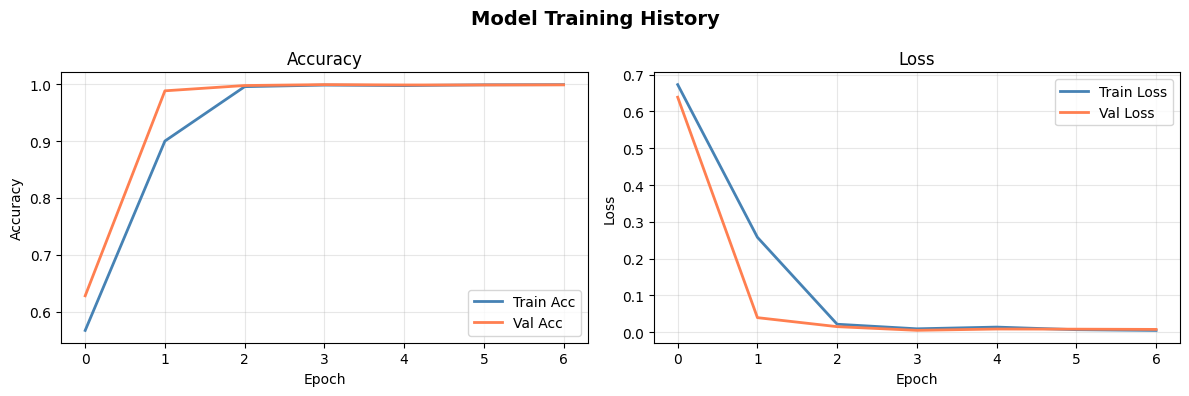

✅ Training history plot saved


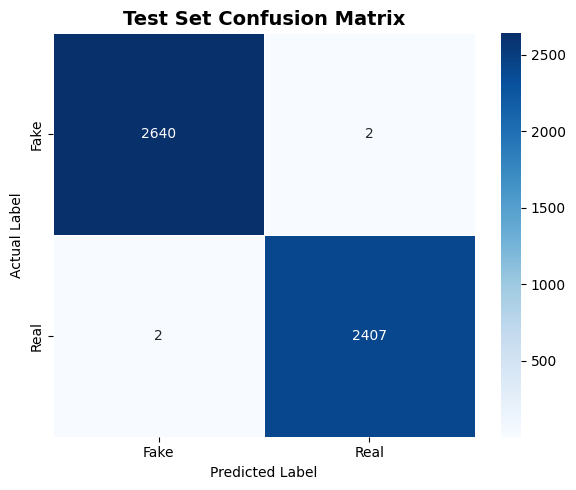

✅ Confusion matrix plot saved


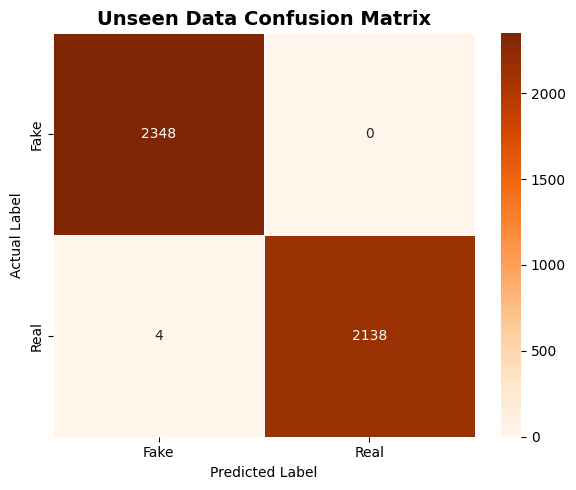

✅ Unseen confusion matrix plot saved


In [17]:
import json

# Plot 1: Training History
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model Training History", fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'], label='Train Acc', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc', color='coral', linewidth=2)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', color='coral', linewidth=2)
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history plot saved")

# Plot 2: Test Set Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            linewidths=0.5)
plt.title("Test Set Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix plot saved")

# Plot 3: Unseen Data Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(unseen_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            linewidths=0.5)
plt.title("Unseen Data Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "unseen_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Unseen confusion matrix plot saved")

## Step 13: Save Model & Metrics

In [18]:
# Save final model
model.save(os.path.join(OUTPUT_DIR, "lstm_fake_news_model.keras"))
print("✅ Model saved: lstm_fake_news_model.keras")

# Save training metrics as JSON
metrics = {
    "test_accuracy": round(acc * 100, 2),
    "unseen_accuracy": round(unseen_acc * 100, 2),
    "train_accuracy": [round(v * 100, 2) for v in history.history['accuracy']],
    "val_accuracy": [round(v * 100, 2) for v in history.history['val_accuracy']],
    "train_loss": [round(v, 4) for v in history.history['loss']],
    "val_loss": [round(v, 4) for v in history.history['val_loss']],
    "epochs_run": len(history.history['accuracy']),
    "data_split": "80% Train, 10% Test, 10% Unseen"
}

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("✅ Metrics saved: metrics.json")

✅ Model saved: lstm_fake_news_model.keras
✅ Metrics saved: metrics.json


## Step 14: Download Artifacts

In [19]:
print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE")
print("=" * 60)
print(f"\n  Final Test Accuracy: {acc * 100:.2f}%")
print(f"  Final Unseen Accuracy: {unseen_acc * 100:.2f}%")
print(f"\n  Data split: 80% Train, 10% Test, 10% Unseen")
print(f"\n  All artifacts saved to '{OUTPUT_DIR}/' folder:")
print(f"    ✓ lstm_fake_news_model.keras")
print(f"    ✓ tokenizer.pkl")
print(f"    ✓ training_history.png")
print(f"    ✓ confusion_matrix.png")
print(f"    ✓ unseen_confusion_matrix.png")
print(f"    ✓ metrics.json\n")


✅ TRAINING COMPLETE

  Final Test Accuracy: 99.92%
  Final Unseen Accuracy: 99.91%

  Data split: 80% Train, 10% Test, 10% Unseen

  All artifacts saved to 'model_artifacts/' folder:
    ✓ lstm_fake_news_model.keras
    ✓ tokenizer.pkl
    ✓ training_history.png
    ✓ confusion_matrix.png
    ✓ unseen_confusion_matrix.png
    ✓ metrics.json



## Step 15: Download model_artifacts Folder

In [20]:
# Compress and download the model_artifacts folder
!zip -r model_artifacts.zip model_artifacts/ -q

from google.colab import files
files.download('model_artifacts.zip')

print("\n✅ Downloaded: model_artifacts.zip")
print("   Extract this on your local machine and replace your old 'Artifacts' folder")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloaded: model_artifacts.zip
   Extract this on your local machine and replace your old 'Artifacts' folder
